<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/HomeWork/HousePriceANN(using_numpy%26pytorch_classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
!pip install opendatasets

In [138]:
import opendatasets as od

In [139]:
od.download('https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv')

Skipping, found downloaded files in "./house-prices-advanced-regression-techniques" (use force=True to force download)


In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [141]:
df_test=pd.read_csv('/content/house-prices-advanced-regression-techniques/test.csv')
df_train=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
print("train_shape: ",df_train.shape)
print("test_shape: ",df_test.shape)

train_shape:  (1460, 81)
test_shape:  (1459, 80)


In [142]:
df_train['SalePrice'] = pd.qcut(
    df_train['SalePrice'],
    q = 3,
    labels = ['low', 'medium', 'high']
)

In [143]:
pd.set_option('display.max_columns', None)
df_train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,high
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,medium
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,high


In [144]:
class_map = {'low': 0, 'medium':1, 'high':2}
df_train['SalePrice'] = df_train['SalePrice'].map(class_map)

df_train.sample(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1384,1385,50,RL,60.0,9060,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1.5Fin,6,5,1939,1950,Gable,CompShg,WdShing,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,Mn,Rec,204,Unf,0,356,560,GasA,TA,Y,SBrkr,698,560,0,1258,0,0,1,0,2,1,TA,6,Typ,0,NaN,Detchd,1939.0,Unf,1,280,TA,TA,P,0,0,0,0,0,0,NaN,MnPrv,NaN,0,10,2009,WD,Normal,0
660,661,60,RL,NaN,12384,Pave,NaN,Reg,Lvl,AllPub,CulDSac,Gtl,NWAmes,Norm,Norm,1Fam,2Story,7,7,1976,1976,Gable,CompShg,Plywood,Plywood,BrkFace,233.0,TA,TA,CBlock,Gd,TA,No,Unf,0,Unf,0,793,793,GasA,TA,Y,SBrkr,1142,793,0,1935,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1976.0,RFn,2,550,TA,TA,Y,0,113,252,0,0,0,NaN,NaN,NaN,0,11,2007,WD,Normal,2
728,729,90,RL,85.0,11475,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,Duplex,1Story,5,5,1958,1958,Gable,CompShg,VinylSd,VinylSd,BrkFace,95.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,1584,1584,GasA,TA,Y,SBrkr,1776,0,0,1776,1,0,2,0,4,2,TA,9,Typ,0,NaN,Detchd,1968.0,Unf,3,888,TA,TA,Y,0,25,0,0,0,0,NaN,NaN,NaN,0,7,2009,COD,Abnorml,0


In [145]:
df_train.isnull().sum().sort_values(ascending=False).head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [146]:
df_train.duplicated().sum()

np.int64(0)

In [147]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

In [148]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [149]:
missing=df_train.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(5)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872


In [150]:
for df in [df_train, df_test]:
    for col in df.columns:
        if df[col].dtype.name == 'category' or df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-2769437982.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2769437982.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [151]:
df_train.isnull().sum().sum()

np.int64(0)

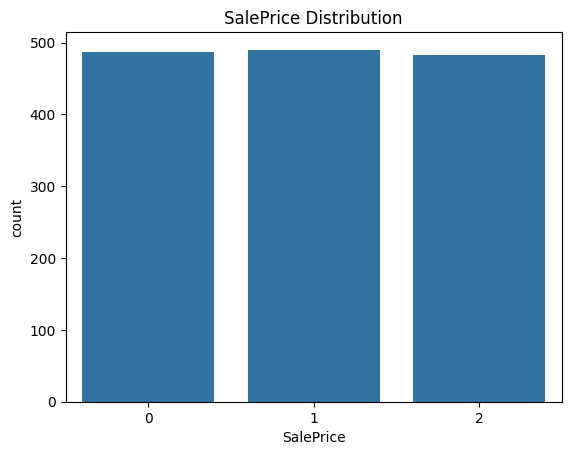

In [152]:
sns.countplot(x=df_train['SalePrice'])  # x= লাগানো উচিত
plt.title("SalePrice Distribution")
plt.show()

In [153]:
train = df_train.copy()
test = df_test.copy()

In [154]:
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0)

# obj_cols
obj_cols = all_data.select_dtypes(include='object').columns

le = LabelEncoder()
for col in obj_cols:
    all_data[col] = le.fit_transform(all_data[col])
# all_data.sample(10)

X = all_data.iloc[:train.shape[0], :]
X_test_final = all_data.iloc[train.shape[0]:, :]
y = train['SalePrice']

In [155]:
from sklearn.preprocessing import  StandardScaler, RobustScaler

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [157]:
# Feature Scaling (X)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [158]:
# Target Scaling (y)
scaler_y = RobustScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

In [159]:
X_train_np = X_train_scaled.astype(np.float32)
X_test_np  = X_test_scaled.astype(np.float32)

# y must be 0 or 1 (NO scaling)
y_train_np = y_train.to_numpy().astype(int).reshape(-1)
y_test_np  = y_test.to_numpy().astype(int).reshape(-1)


In [160]:
def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

In [161]:
num_classes = 3
y_train_oh = one_hot(y_train_np, num_classes)
y_test_oh   = one_hot(y_test_np, num_classes)
print(y_train_oh.shape)  # (num_samples, 3)
print(y_test_oh.shape)

(1168, 3)
(292, 3)


In [162]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def categorical_cross_entropy(y_pred, y_true):
    eps = 1e-7
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))


In [163]:
class MulticlassANN:

    def __init__(self, input_dim, num_classes, lr=0.001):
        self.lr = lr

        self.W1 = np.random.randn(input_dim, 64) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, 64))

        self.W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
        self.b2 = np.zeros((1, 32))

        self.W3 = np.random.randn(32, num_classes) * np.sqrt(2 / 32)
        self.b3 = np.zeros((1, num_classes))

    def forward(self, X):
        self.X = X

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = relu(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.y_pred = softmax(self.z3)

        return self.y_pred

    def backward(self, y_true):
        n = y_true.shape[0]

        dz3 = self.y_pred - y_true
        dW3 = np.dot(self.a2.T, dz3) / n
        db3 = np.sum(dz3, axis=0, keepdims=True) / n

        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * relu_derivative(self.z2)
        dW2 = np.dot(self.a1.T, dz2) / n
        db2 = np.sum(dz2, axis=0, keepdims=True) / n

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = np.dot(self.X.T, dz1) / n
        db1 = np.sum(dz1, axis=0, keepdims=True) / n

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


In [164]:
model = MulticlassANN(
    input_dim=X_train_np.shape[1],
    num_classes=3,
    lr=0.001
)


In [165]:
epochs = 500
train_losses = []
val_losses   = []

for epoch in range(epochs):

    # --- Forward & Backward ---
    y_pred_train = model.forward(X_train_np)
    train_loss = categorical_cross_entropy(y_pred_train, y_train_oh)
    train_losses.append(train_loss)

    model.backward(y_train_oh)

    # --- Validation loss ---
    y_pred_val = model.forward(X_test_np)
    val_loss = categorical_cross_entropy(y_pred_val, y_test_oh)
    val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


Epoch [20/500] - Train Loss: 1.8677 - Val Loss: 1.9364
Epoch [40/500] - Train Loss: 1.6371 - Val Loss: 1.6973
Epoch [60/500] - Train Loss: 1.4655 - Val Loss: 1.5196
Epoch [80/500] - Train Loss: 1.3381 - Val Loss: 1.3880
Epoch [100/500] - Train Loss: 1.2431 - Val Loss: 1.2899
Epoch [120/500] - Train Loss: 1.1711 - Val Loss: 1.2158
Epoch [140/500] - Train Loss: 1.1154 - Val Loss: 1.1583
Epoch [160/500] - Train Loss: 1.0713 - Val Loss: 1.1128
Epoch [180/500] - Train Loss: 1.0357 - Val Loss: 1.0758
Epoch [200/500] - Train Loss: 1.0062 - Val Loss: 1.0450
Epoch [220/500] - Train Loss: 0.9812 - Val Loss: 1.0187
Epoch [240/500] - Train Loss: 0.9594 - Val Loss: 0.9958
Epoch [260/500] - Train Loss: 0.9402 - Val Loss: 0.9756
Epoch [280/500] - Train Loss: 0.9230 - Val Loss: 0.9575
Epoch [300/500] - Train Loss: 0.9073 - Val Loss: 0.9412
Epoch [320/500] - Train Loss: 0.8929 - Val Loss: 0.9263
Epoch [340/500] - Train Loss: 0.8796 - Val Loss: 0.9126
Epoch [360/500] - Train Loss: 0.8671 - Val Loss: 0.8

In [166]:
y_test_pred = model.forward(X_test_np)
y_test_class = np.argmax(y_test_pred, axis=1)

accuracy = np.mean(y_test_class == y_test_np)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.6027397260273972


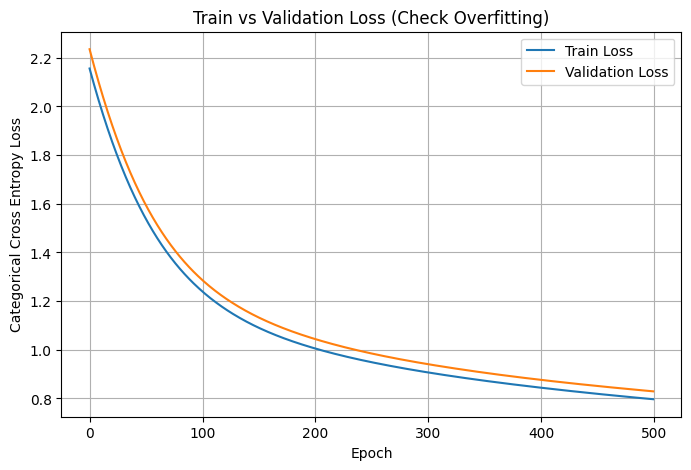

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross Entropy Loss")
plt.title("Train vs Validation Loss (Check Overfitting)")
plt.legend()
plt.grid(True)
plt.show()


# Using Pytorch

In [168]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [170]:
class HousePriceClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=3, drop_prob=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(drop_prob),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)  # Linear output
        )
    def forward(self, x):
        return self.model(x)

In [171]:
model = HousePriceClassifier(input_dim=X_tr_tensor.shape[1], num_classes=3, drop_prob=0.3)

In [172]:
criterion = nn.CrossEntropyLoss()  # Combines Softmax + NLLLoss
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [176]:
epochs = 500
train_losses = []
val_losses = []

model.train()  # Dropout ON

for epoch in range(epochs):
    # Forward
    y_pred = model(X_tr_tensor)

    # Loss
    loss = criterion(y_pred, y_tr_tensor)
    train_losses.append(loss.item())

    # Backward + update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation loss
    model.eval()  # Dropout OFF
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        val_loss = criterion(y_val_pred, y_val_tensor)
        val_losses.append(val_loss.item())
    model.train()  # Back to training mode

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f}")


Epoch [20/500] - Train Loss: 0.8725 - Val Loss: 0.8854
Epoch [40/500] - Train Loss: 0.8442 - Val Loss: 0.8559
Epoch [60/500] - Train Loss: 0.8147 - Val Loss: 0.8266
Epoch [80/500] - Train Loss: 0.7796 - Val Loss: 0.7986
Epoch [100/500] - Train Loss: 0.7522 - Val Loss: 0.7726
Epoch [120/500] - Train Loss: 0.7226 - Val Loss: 0.7488
Epoch [140/500] - Train Loss: 0.7097 - Val Loss: 0.7271
Epoch [160/500] - Train Loss: 0.6849 - Val Loss: 0.7076
Epoch [180/500] - Train Loss: 0.6671 - Val Loss: 0.6901
Epoch [200/500] - Train Loss: 0.6578 - Val Loss: 0.6744
Epoch [220/500] - Train Loss: 0.6292 - Val Loss: 0.6601
Epoch [240/500] - Train Loss: 0.6211 - Val Loss: 0.6471
Epoch [260/500] - Train Loss: 0.5993 - Val Loss: 0.6354
Epoch [280/500] - Train Loss: 0.5904 - Val Loss: 0.6245
Epoch [300/500] - Train Loss: 0.5821 - Val Loss: 0.6146
Epoch [320/500] - Train Loss: 0.5669 - Val Loss: 0.6054
Epoch [340/500] - Train Loss: 0.5688 - Val Loss: 0.5969
Epoch [360/500] - Train Loss: 0.5513 - Val Loss: 0.5

In [177]:
model.eval()
with torch.no_grad():
    y_val_pred = model(X_val_tensor)
    y_val_classes = torch.argmax(y_val_pred, dim=1)
    val_acc = (y_val_classes == y_val_tensor).float().mean()
    print("Validation Accuracy:", val_acc.item())


Validation Accuracy: 0.7896995544433594


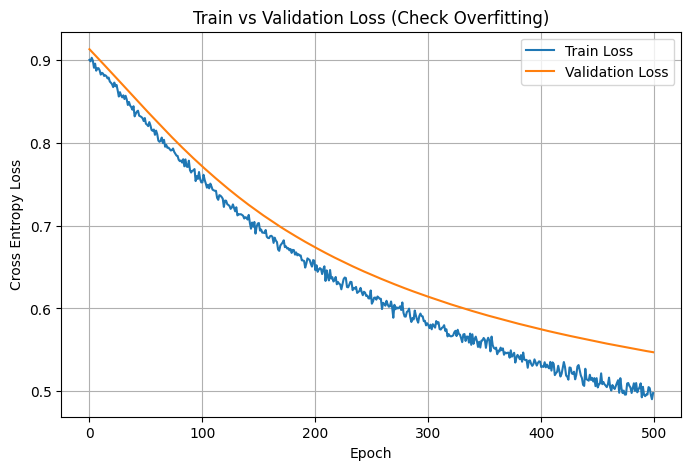

In [178]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Train vs Validation Loss (Check Overfitting)")
plt.legend()
plt.grid(True)
plt.show()
